Kaggle Dataset: Loan Approval Classification Dataset

https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

In [1]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
import math

In [2]:
# load the dataset from Kaggle
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")
print("Path to dataset files:", path)

data = pd.read_csv(path + "\loan_data.csv")
print(data.shape)
print(data.head())

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
C:\Users\sunsh\AppData\Local\Temp\ipykernel_42496\3125445034.py:5: SyntaxWarning: invalid escape sequence '\l'
  data = pd.read_csv(path + "\loan_data.csv")


Path to dataset files: C:\Users\sunsh\.cache\kagglehub\datasets\taweilo\loan-approval-classification-data\versions\1
(45000, 14)
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   lo

In [3]:
# Understand the variations of each column
numerical_columns = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
categorical_columns = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
for col in numerical_columns:
    print(f"Column: {col}, Min: {data[col].min()}, Max: {data[col].max()}")
for col in categorical_columns:
    print(f"Column: {col}, Unique values: {data[col].unique()}")

Column: person_age, Min: 20.0, Max: 144.0
Column: person_income, Min: 8000.0, Max: 7200766.0
Column: person_emp_exp, Min: 0, Max: 125
Column: loan_amnt, Min: 500.0, Max: 35000.0
Column: loan_int_rate, Min: 5.42, Max: 20.0
Column: loan_percent_income, Min: 0.0, Max: 0.66
Column: cb_person_cred_hist_length, Min: 2.0, Max: 30.0
Column: credit_score, Min: 390, Max: 850
Column: person_gender, Unique values: ['female' 'male']
Column: person_education, Unique values: ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
Column: person_home_ownership, Unique values: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
Column: loan_intent, Unique values: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
Column: previous_loan_defaults_on_file, Unique values: ['No' 'Yes']


In [4]:
# Perform some basic data cleaning
data = data.dropna()
data = data[(data['person_age'] >= 18) & (data['person_age'] <= 60)]
data = data[(data['person_income'] >= 12000) & (data['person_income'] <= 240000)]
data = data[(data['person_emp_exp'] >= 1) & (data['person_emp_exp'] <= 40)]
data = data[data['loan_percent_income'] > 0.01]
data.reset_index(drop=True, inplace=True)

print(data.shape)
print(data.head())

(34392, 14)
   person_age person_gender person_education  person_income  person_emp_exp  \
0        25.0        female      High School        12438.0               3   
1        24.0          male           Master        66135.0               1   
2        26.0        female         Bachelor        93471.0               1   
3        24.0        female      High School        95550.0               5   
4        24.0        female        Associate       100684.0               3   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0              MORTGAGE     5500.0     MEDICAL          12.87   
1                  RENT    35000.0     MEDICAL          14.27   
2                  RENT    35000.0   EDUCATION          12.42   
3                  RENT    35000.0     MEDICAL          11.11   
4                  RENT    35000.0    PERSONAL           8.90   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.44                         3.0    

In [5]:
# Split the data into features and target variable
X = data.iloc[:, :13]
y = data.iloc[:, 13]

In [6]:
def plot_data_samples(feature1, feature2, label1, label2):
    sample_indices = data.sample(n=1000, random_state=17).index
    approved = y.loc[sample_indices].values.flatten() == 1
    rejected = y.loc[sample_indices].values.flatten() == 0
    feature1 = feature1.loc[sample_indices]
    feature2 = feature2.loc[sample_indices]

    plt.plot(feature1[approved], feature2[approved], 'k+', label='Approved')
    plt.plot(feature1[rejected], feature2[rejected], 'yo', label='Rejected')

    plt.xlabel(label1)
    plt.ylabel(label2)

    plt.title('Loan Approval Decisions')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()

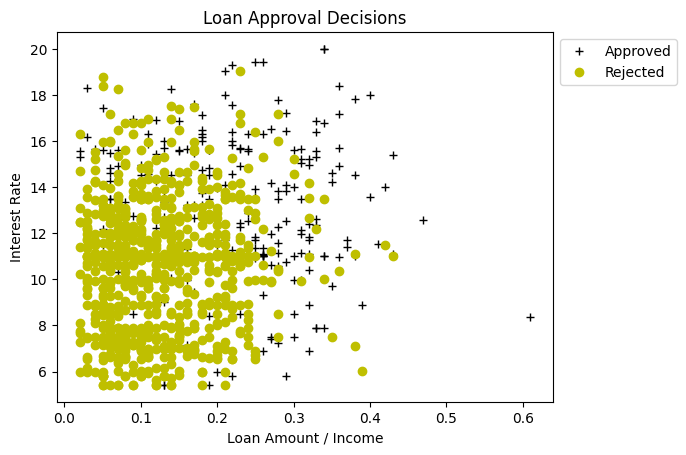

In [7]:
plot_data_samples(X['loan_percent_income'], X['loan_int_rate'], 'Loan Amount / Income', 'Interest Rate')

C:\Users\sunsh\AppData\Local\Temp\ipykernel_42496\3773317635.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(approval_rate_edu.index.astype(str), rotation=45)
C:\Users\sunsh\AppData\Local\Temp\ipykernel_42496\3773317635.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(approval_rate_income.index.astype(str), rotation=45)
C:\Users\sunsh\AppData\Local\Temp\ipykernel_42496\3773317635.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[4].set_xticklabels(approval_rate_intent.index.astype(str), rotation=45)


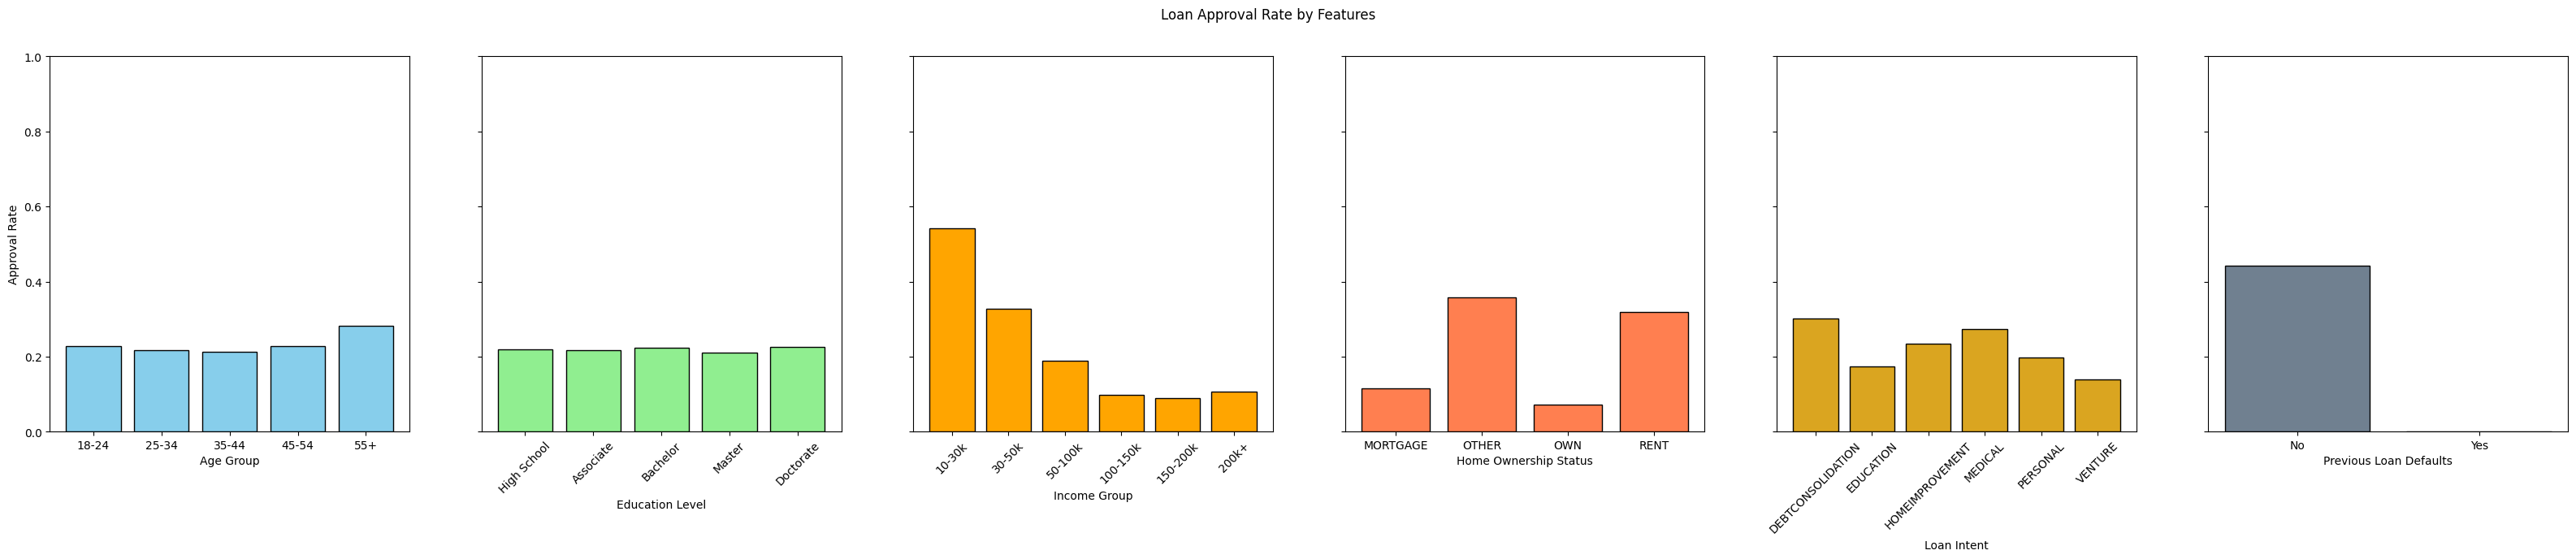

In [8]:
# Create categorical groups for numerical column person_age
age_bins = [18, 25, 35, 45, 55, 65]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55+']
data['age_group'] = pd.cut(data['person_age'], bins=age_bins, labels=age_labels, right=False)

# Order categorical column person_education for better visualization
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']
data['person_education'] = pd.Categorical(data['person_education'], categories=education_order, ordered=True)

# Create categorical groups for numerical column person_income
income_bins = [10000, 30000, 50000, 100000, 150000, 200000, 300000]
income_labels = ['10-30k', '30-50k', '50-100k', '100-150k', '150-200k', '200k+']
data['income_group'] = pd.cut(data['person_income'], bins=income_bins, labels=income_labels, right=False)

fig, ax = plt.subplots(1, 6, figsize=(40, 6), sharey=True)

approval_rate_age = data.groupby('age_group', observed=True)['loan_status'].mean()
ax[0].bar(approval_rate_age.index.astype(str), approval_rate_age.values, color='skyblue', edgecolor='black')
ax[0].set_xlabel('Age Group')

approval_rate_edu = data.groupby('person_education', observed=True)['loan_status'].mean()
ax[1].bar(approval_rate_edu.index.astype(str), approval_rate_edu.values, color='lightgreen', edgecolor='black')
ax[1].set_xlabel('Education Level')
ax[1].set_xticklabels(approval_rate_edu.index.astype(str), rotation=45)

approval_rate_income = data.groupby('income_group', observed=True)['loan_status'].mean()
ax[2].bar(approval_rate_income.index.astype(str), approval_rate_income.values, color='orange', edgecolor='black')
ax[2].set_xlabel('Income Group')
ax[2].set_xticklabels(approval_rate_income.index.astype(str), rotation=45)

approval_rate_home = data.groupby('person_home_ownership', observed=True)['loan_status'].mean()
ax[3].bar(approval_rate_home.index.astype(str), approval_rate_home.values, color='coral', edgecolor='black')
ax[3].set_xlabel('Home Ownership Status')

approval_rate_intent = data.groupby('loan_intent', observed=True)['loan_status'].mean()
ax[4].bar(approval_rate_intent.index.astype(str), approval_rate_intent.values, color='goldenrod', edgecolor='black')
ax[4].set_xlabel('Loan Intent')
ax[4].set_xticklabels(approval_rate_intent.index.astype(str), rotation=45)

approval_rate_defaults = data.groupby('previous_loan_defaults_on_file', observed=True)['loan_status'].mean()
ax[5].bar(approval_rate_defaults.index.astype(str), approval_rate_defaults.values, color='slategray', edgecolor='black')
ax[5].set_xlabel('Previous Loan Defaults')

fig.suptitle('Loan Approval Rate by Features')
ax[0].set_ylabel('Approval Rate')
ax[0].set_ylim(0, 1)

plt.show()

In [9]:
# Perform one-hot encoding for categorical variables
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)
print(X.shape)

(34392, 22)


In [10]:
# Split the data into training and testing sets
train_size = int(0.9 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(30952, 22)
(3440, 22)


In [11]:
# Perform feature scaling
scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
print(X_train.head(5))

X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

   person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  \
0   -0.676247      -1.659179       -0.665207  -0.661506       0.663964   
1   -0.848497      -0.296843       -1.017878   4.113246       1.135999   
2   -0.503996       0.396693       -1.017878   4.113246       0.512239   
3   -0.848497       0.449439       -0.312535   4.113246       0.070549   
4   -0.848497       0.579693       -0.665207   4.113246      -0.674592   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0             3.639738                   -0.879303     -0.000578   
1             4.719535                   -0.628793     -0.978688   
2             2.799895                   -0.879303      1.316875   
3             2.799895                   -0.628793     -0.998650   
4             2.559940                   -1.129813     -1.817068   

   person_gender_male  person_education_Bachelor  ...  \
0               False                      False  ...   
1                True           

C:\Users\sunsh\AppData\Local\Temp\ipykernel_42496\1136539957.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
C:\Users\sunsh\AppData\Local\Temp\ipykernel_42496\1136539957.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])


In [12]:


def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z
         
    """

    # if z is a scalar, convert it to a numpy array
    if np.isscalar(z):
        z = np.array(z)
    z = z.astype(float)
    g = 1/(1+np.exp(-z))
     
    
    return g

In [13]:
print ("sigmoid(0) = " + str(sigmoid(np.array(0))))

sigmoid(0) = 0.5


In [14]:
def sigmoid_test(target):
    assert np.isclose(target(3.0), 0.9525741268224334), "Failed for scalar input"
    assert np.allclose(target(np.array([2.5, 0])), [0.92414182, 0.5]), "Failed for 1D array"
    assert np.allclose(target(np.array([[2.5, -2.5], [0, 1]])), 
                       [[0.92414182, 0.07585818], [0.5, 0.73105858]]), "Failed for 2D array"
    print('\033[92mAll tests passed!')

In [15]:
print ("sigmoid([ -1, 0, 1, 2]) = " + str(sigmoid(np.array([-1, 0, 1, 2]))))

# UNIT TESTS
sigmoid_test(sigmoid)

sigmoid([ -1, 0, 1, 2]) = [0.26894142 0.5        0.73105858 0.88079708]
All tests passed!


In [16]:
def compute_cost(X, y, w, b, lambda_= 1):
    """
    Computes the cost over all examples
    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (array_like Shape (m,)) target value 
      w : (array_like Shape (n,)) Values of parameters of the model      
      b : scalar Values of bias parameter of the model
      lambda_: unused placeholder
    Returns:
      total_cost: (scalar)         cost 
    """

    m, n = X.shape
    
    cost = 0
    for i in range(m):
        z = np.dot(X[i],w) + b
        f_wb = sigmoid(z)
        cost += -y[i]*np.log(f_wb) - (1-y[i])*np.log(1-f_wb)
    total_cost = cost/m
    

    return total_cost

In [17]:
m, n = X_train.shape
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)
# Compute and display cost with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost(X_train, y_train, initial_w, initial_b)
print('Cost at initial w (zeros): {:.3f}'.format(cost))

Cost at initial w (zeros): 0.693


In [18]:
def compute_cost_test(target):
    X = np.array([[0, 0, 0, 0]]).T
    y = np.array([0, 0, 0, 0])
    w = np.array([0])
    b = 1
    result = target(X, y, w, b)
    if math.isinf(result):
        raise ValueError("Did you get the sigmoid of z_wb?")
    
    np.random.seed(17)  
    X = np.random.randn(5, 2)
    y = np.array([1, 0, 0, 1, 1])
    w = np.random.randn(2)
    b = 0
    result = target(X, y, w, b)
    assert np.isclose(result, 2.15510667), f"Wrong output. Expected: {2.15510667} got: {result}"
    
    X = np.random.randn(4, 3)
    y = np.array([1, 1, 0, 0])
    w = np.random.randn(3)
    b = 0
    
    result = target(X, y, w, b)
    assert np.isclose(result, 0.80709376), f"Wrong output. Expected: {0.80709376} got: {result}"

    X = np.random.randn(4, 3)
    y = np.array([1, 0,1, 0])
    w = np.random.randn(3)
    b = 3
    result = target(X, y, w, b)
    assert np.isclose(result, 0.4529660647), f"Wrong output. Expected: {0.4529660647} got: {result}. Did you inizialized z_wb = b?"
    
    print('\033[92mAll tests passed!')

In [19]:
# Compute and display cost with non-zero w
test_w = np.array([0.2 for i in range(n)])
test_b = -24.
cost = compute_cost(X_train, y_train, test_w, test_b)

print('Cost at test w,b: {:.3f}'.format(cost))


# UNIT TESTS
compute_cost_test(compute_cost)


Cost at test w,b: 3.954
All tests passed!


In [20]:
def compute_gradient(X, y, w, b, lambda_=None): 
    """
    Computes the gradient for logistic regression 
 
    Args:
      X : (ndarray Shape (m,n)) variable such as house size 
      y : (array_like Shape (m,1)) actual value 
      w : (array_like Shape (n,1)) values of parameters of the model      
      b : (scalar)                 value of parameter of the model 
      lambda_: unused placeholder.
    Returns
      dj_dw: (array_like Shape (n,1)) The gradient of the cost w.r.t. the parameters w. 
      dj_db: (scalar)                The gradient of the cost w.r.t. the parameter b. 
    """
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

 
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)          
        err_i  = f_wb_i  - y[i]                       
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * X[i,j]      
        dj_db = dj_db + err_i
    dj_dw = dj_dw/m                                   
    dj_db = dj_db/m                                   
        


        
    return dj_db, dj_dw

In [21]:
# Compute and display gradient with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w (zeros):{dj_db}' )
print(f'dj_dw at initial w (zeros):{dj_dw.tolist()}' )

dj_db at initial w (zeros):0.32951020935642283
dj_dw at initial w (zeros):[0.0015372845845725961, 0.07766471451030173, -0.0018407253576574183, -0.04061693347569944, -0.11565729755035409, -0.13200748432493106, 0.0021004454209742093, 0.003519258034434469, 0.18144223313517704, 0.09695657792711294, 0.0055408374256913934, 0.08466334970276557, 0.052226027397260275, 0.00046846730421297493, 0.02978805892995606, 0.125, 0.06909085034892737, 0.03699276298785216, 0.054358361333677954, 0.05834841044197467, 0.0694947014732489, 0.2684640734039804]


In [22]:
def compute_gradient_test(target):
    np.random.seed(1)
    X = np.random.randn(7, 3)
    y = np.array([1, 0, 1, 0, 1, 1, 0])
    test_w = np.array([1, 0.5, -0.35])
    test_b = 1.7
    dj_db, dj_dw  = target(X, y, test_w, test_b)
    
    assert np.isclose(dj_db, 0.28936094), f"Wrong value for dj_db. Expected: {0.28936094} got: {dj_db}" 
    assert dj_dw.shape == test_w.shape, f"Wrong shape for dj_dw. Expected: {test_w.shape} got: {dj_dw.shape}" 
    assert np.allclose(dj_dw, [-0.11999166, 0.41498775, -0.71968405]), f"Wrong values for dj_dw. Got: {dj_dw}"

    print('\033[92mAll tests passed!') 

In [23]:
    
compute_gradient_test(compute_gradient)


All tests passed!


In [24]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X :    (array_like Shape (m, n)
      y :    (array_like Shape (m,))
      w_in : (array_like Shape (n,))  Initial values of parameters of the model
      b_in : (scalar)                 Initial value of parameter of the model
      cost_function:                  function to compute cost
      alpha : (float)                 Learning rate
      num_iters : (int)               number of iterations to run gradient descent
      lambda_ (scalar, float)         regularization constant
      
    Returns:
      w : (array_like Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(X)
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)   

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw               
        b_in = b_in - alpha * dj_db              
       
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

In [25]:
np.random.seed(1)
initial_w = 0.01 * (np.random.rand(22).reshape(-1,1) - 0.5)
initial_b = 0.01

# Some gradient descent settings
iterations = 100
alpha = 0.5

w,b, J_history,_ = gradient_descent(X_train ,y_train, initial_w, initial_b, 
                                   compute_cost, compute_gradient, alpha, iterations, 0)

C:\Users\sunsh\AppData\Local\Temp\ipykernel_42496\4135190203.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")


Iteration    0: Cost     0.56   
Iteration   10: Cost     0.33   
Iteration   20: Cost     0.30   
Iteration   30: Cost     0.28   
Iteration   40: Cost     0.27   
Iteration   50: Cost     0.26   
Iteration   60: Cost     0.25   
Iteration   70: Cost     0.25   
Iteration   80: Cost     0.24   
Iteration   90: Cost     0.24   
Iteration   99: Cost     0.24   


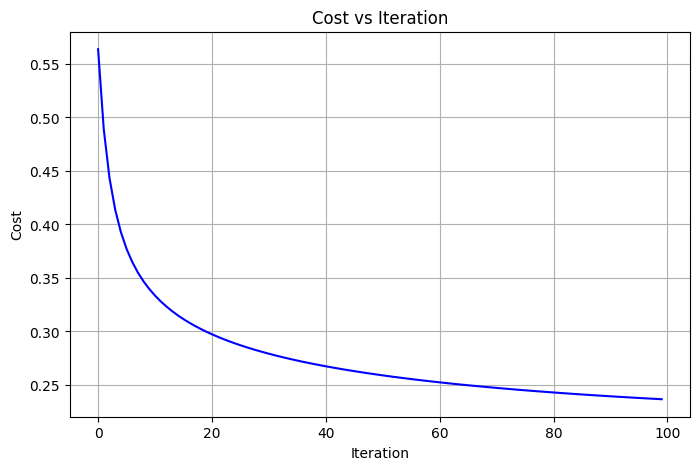

In [26]:
# plot the cost function over iterations
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), J_history, color='blue')
plt.title('Cost vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [27]:
def predict(X, w, b): 
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w
    
    Args:
    X : (ndarray Shape (m, n))
    w : (array_like Shape (n,))      Parameters of the model
    b : (scalar, float)              Parameter of the model

    Returns:
    p: (ndarray (m,1))
        The predictions for X using a threshold at 0.5
    """
    # number of training examples
    m, n = X.shape   
    p = np.zeros(m)

    # Loop over each example
    for i in range(m):   
        z_wb = np.dot(X[i],w) 
        # Loop over each feature
        for j in range(n): 
            # Add the corresponding term to z_wb
            z_wb += 0
        
        # Add bias term 
        z_wb += b
        
        # Calculate the prediction for this example
        f_wb = sigmoid(z_wb)

        # Apply the threshold
        p[i] = 1 if f_wb>0.5 else 0

    return p


In [28]:
def predict_test(target):
    np.random.seed(5)
    b = 0.5    
    w = np.random.randn(3)
    X = np.random.randn(8, 3)
    
    result = target(X, w, b)
    wrong_1 = [1., 1., 0., 0., 1., 0., 0., 1.]
    expected_1 = [1., 1., 1., 0., 1., 0., 0., 1.]
    if np.allclose(result, wrong_1):
        raise ValueError("Did you apply the sigmoid before applying the threshold?")
    assert result.shape == (len(X),), f"Wrong length. Expected : {(len(X),)} got: {result.shape}"
    assert np.allclose(result, expected_1), f"Wrong output: Expected : {expected_1} got: {result}"
    
    b = -1.7    
    w = np.random.randn(4) + 0.6
    X = np.random.randn(6, 4)
    
    result = target(X, w, b)
    expected_2 = [0., 0., 0., 1., 1., 0.]
    assert result.shape == (len(X),), f"Wrong length. Expected : {(len(X),)} got: {result.shape}"
    assert np.allclose(result,expected_2), f"Wrong output: Expected : {expected_2} got: {result}"

    print('\033[92mAll tests passed!')

In [29]:
np.random.seed(1)
tmp_w = np.random.randn(2)
tmp_b = 0.3    
tmp_X = np.random.randn(4, 2) - 0.5

tmp_p = predict(tmp_X, tmp_w, tmp_b)
print(f'Output of predict: shape {tmp_p.shape}, value {tmp_p}')

# UNIT TESTS        
predict_test(predict)

Output of predict: shape (4,), value [0. 1. 1. 1.]
All tests passed!


In [30]:
# predict loan status with the testing set
y_pred = predict(X_test, w, b)
print(f"Test Accuracy: {np.mean(y_pred == y_test) * 100:.2f}%")

Test Accuracy: 71.95%


In [31]:
# compute cost with the testing set
test_cost = compute_cost(X_test, y_test, w, b)
print(f"test Cost: {test_cost[0]:.2f}")

test Cost: 0.53
